Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries imported
✅ Model loaded
✅ Scaler loaded
✅ Model config loaded
   Sequence length: 12
✅ Features: 12
✅ Data loaded: 4707 rows

🔍 CHECKING RAW DATA FOR NaN VALUES
Total NaN in raw data: 0

NaN count by column:
Series([], dtype: int64)

NaN values in target column: 0 (0.00%)

🧹 CLEANING DATA - REMOVING NaN VALUES
After removing target NaNs: 4707 rows (0 removed)
After removing extreme values: 4704 rows

✅ Final clean data: 4704 rows

📊 SPLITTING CLEAN DATA
Train set: 3763 rows
Test set: 941 rows
✅ Using 941 rows for validation

🔧 PREPARING TEST DATA

🔍 FINAL NaN CHECK:
NaN in X_test: 0
NaN in y_test: 0

✅ Features created: 12 features
   X shape: (941, 12), y shape: (941,)
✅ Features scaled

🔗 CREATING SEQUENCES
✅ Sequences created:
   X_seq shape: (929, 12, 12)
   y_seq shape: (929,)

🔍 FINAL SEQUENCE CHECK:
NaN in X_seq: 0
NaN in y_seq: 0

🤖 GENERA

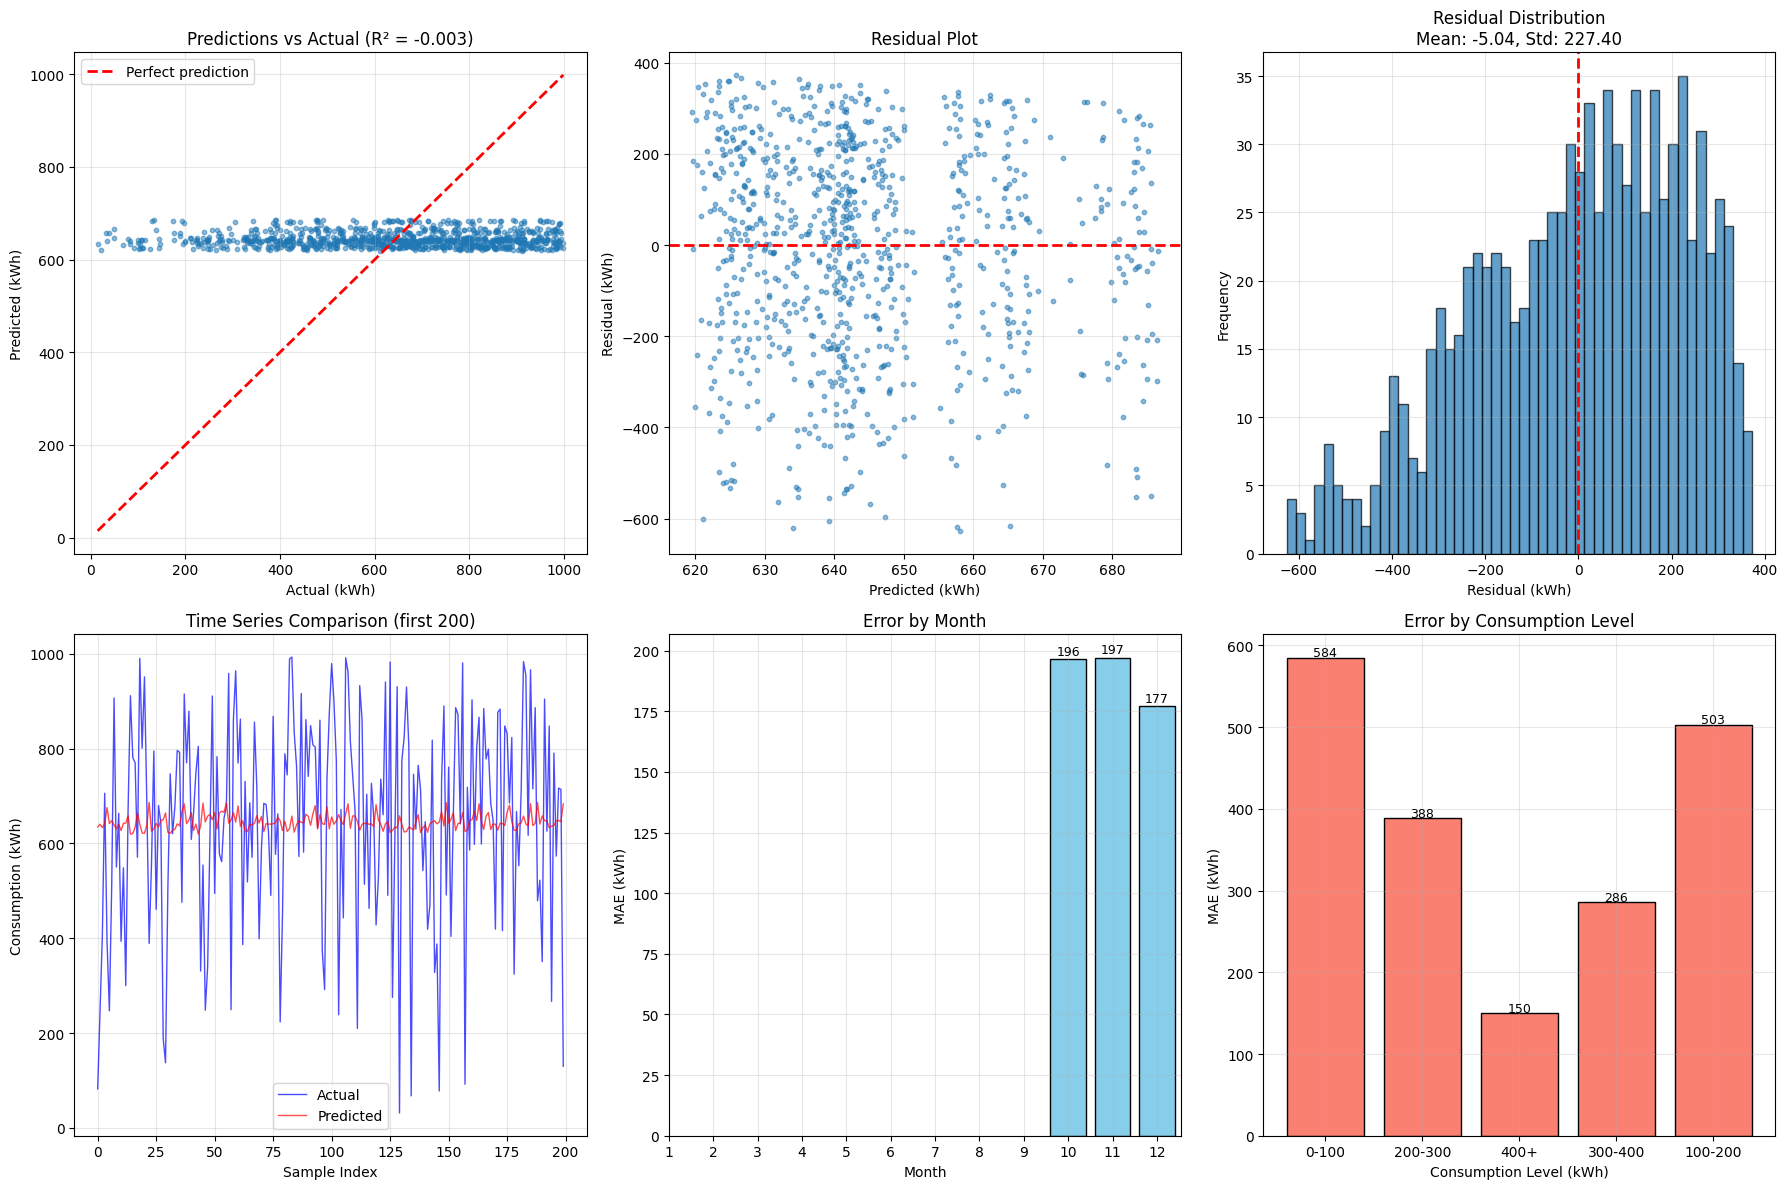


3. ERROR ANALYSIS
----------------------------------------
Mean error: -5.04
Std error: 227.40
Skewness: -0.496
Kurtosis: -0.490
Normality test p-value: 0.0000
Residuals are NOT normal

4. ERROR CORRELATION WITH FEATURES
----------------------------------------
Correlation with MONTH: -0.125
Correlation with HAS_SOLAR: 0.016
Correlation with INV_CAPACITY: -0.000
Correlation with DISTANCE_FROM_TF_M: -0.046

5. PREDICTION RANGE ANALYSIS
----------------------------------------
Unique predicted values: 399
Is model predicting only a few distinct values? False

6. BIAS ANALYSIS
----------------------------------------
Quantile 10%: Actual=327.6, Pred=625.4, Bias=+297.8
Quantile 25%: Actual=478.7, Pred=631.7, Bias=+153.0
Quantile 50%: Actual=667.4, Pred=641.5, Bias=-25.9
Quantile 75%: Actual=822.0, Pred=656.5, Bias=-165.5
Quantile 90%: Actual=916.3, Pred=667.7, Bias=-248.7

7. DURBIN-WATSON STATISTIC
----------------------------------------
DW = 1.9901
   → No significant autocorrelation



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ DIAGNOSIS COMPLETE


<Figure size 640x480 with 0 Axes>

In [ ]:
"""
# 05 - MODEL DIAGNOSIS NOTEBOOK
# Model performance validation and error analysis
**Purpose**: Identify exact problems with current model
"""

# ============================================================
# 1. SETUP - LOAD YOUR EXISTING MODEL AND DATA
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported")


# 2. LOAD YOUR SAVED MODEL AND DATA
# Load your trained model
model_path = "/content/drive/MyDrive/Model Results/lstm_model.h5"
model = tf.keras.models.load_model(model_path)
print("Model loaded")

# Load scaler
scaler_path = "/content/drive/MyDrive/Model Results/scaler.pkl"
scaler = joblib.load(scaler_path)
print("Scaler loaded")

# Load model config
config_path = "/content/drive/MyDrive/Model Results/model_config.json"
with open(config_path, 'r') as f:
    model_config = json.load(f)
print("Model config loaded")
print(f"   Sequence length: {model_config.get('sequence_length', 12)}")

# Load feature info
feature_path = '/content/drive/MyDrive/Model Results/feature_info.json'
with open(feature_path, 'r') as f:
    feature_info = json.load(f)
print(f"Features: {feature_info['n_features']}")

# Load test data
DATA_PATH = "/content/drive/MyDrive/DSGP_Group16_25 26/processed_new/MASTER_DATASET_RESIDENTIAL_ONLY.csv"
df_raw = pd.read_csv(DATA_PATH)
print(f"Data loaded: {len(df_raw)} rows")


# 3. CHECK FOR NaN VALUES IN RAW DATA
print("\n" + "="*60)
print("CHECKING RAW DATA FOR NaN VALUES")
print("="*60)

print(f"Total NaN in raw data: {df_raw.isna().sum().sum()}")
print("\nNaN count by column:")
nan_by_column = df_raw.isna().sum()
print(nan_by_column[nan_by_column > 0])

# Check target variable specifically
target_nan = df_raw['NET_CONSUMPTION_kWh'].isna().sum()
print(f"\nNaN values in target column: {target_nan} ({target_nan/len(df_raw)*100:.2f}%)")


# 4. CLEAN THE DATA FIRST
print("\n" + "="*60)
print("CLEANING DATA - REMOVING NaN VALUES")
print("="*60)

# Remove rows with NaN in target
df_clean = df_raw.dropna(subset=['NET_CONSUMPTION_kWh']).copy()
print(f"After removing target NaNs: {len(df_clean)} rows ({len(df_raw)-len(df_clean)} removed)")

# Remove rows with NaN in key features
key_features = ['MONTH', 'HAS_SOLAR', 'INV_CAPACITY', 'DISTANCE_FROM_TF_M', 'CAL_TARIFF', 'PHASE']
for feat in key_features:
    if feat in df_clean.columns:
        before = len(df_clean)
        df_clean = df_clean.dropna(subset=[feat])
        after = len(df_clean)
        if before - after > 0:
            print(f"Removed {before-after} rows with NaN in {feat}")

# Remove extreme outliers
df_clean = df_clean[(df_clean['NET_CONSUMPTION_kWh'] >= 10) &
                    (df_clean['NET_CONSUMPTION_kWh'] <= 2000)]
print(f"After removing extreme values: {len(df_clean)} rows")

print(f"\nFinal clean data: {len(df_clean)} rows")


# 5. SPLIT INTO TRAIN AND TEST
print("\n" + "="*60)
print("SPLITTING CLEAN DATA")
print("="*60)

# Sort by time first
df_clean = df_clean.sort_values(['YEAR', 'MONTH'])

# Use first 80% for training reference, last 20% for test
train_size = int(0.8 * len(df_clean))
df_train_raw = df_clean.iloc[:train_size].copy()
df_test_raw = df_clean.iloc[train_size:].copy()

print(f"Train set: {len(df_train_raw)} rows")
print(f"Test set: {len(df_test_raw)} rows")

# Limit test size for faster processing
TEST_SIZE = min(5000, len(df_test_raw))
df_test = df_test_raw.sample(n=TEST_SIZE, random_state=42).copy()
print(f"Using {len(df_test)} rows for validation")


# 6. PREPARE FEATURES FOR TEST DATA
print("\n" + "="*60)
print("PREPARING TEST DATA")
print("="*60)

# Create cyclical month features
df_test['month_sin'] = np.sin(2 * np.pi * df_test['MONTH'] / 12)
df_test['month_cos'] = np.cos(2 * np.pi * df_test['MONTH'] / 12)

# Create season flags
holiday_months = [1, 4, 5, 12]
df_test['is_holiday_month'] = df_test['MONTH'].isin(holiday_months).astype(int)

# One-hot encode categorical variables
tariff_dummies = pd.get_dummies(df_test['CAL_TARIFF'], prefix='tariff')
phase_dummies = pd.get_dummies(df_test['PHASE'], prefix='phase')

# Select base features
base_features = ['MONTH', 'month_sin', 'month_cos', 'is_holiday_month',
                 'HAS_SOLAR', 'INV_CAPACITY', 'DISTANCE_FROM_TF_M']

# Combine all features
X_test = pd.concat([
    df_test[base_features],
    tariff_dummies,
    phase_dummies
], axis=1)

# Fill any remaining missing values with 0
X_test = X_test.fillna(0)

# Target variable
y_test = df_test['NET_CONSUMPTION_kWh'].values

# FINAL NaN CHECK
print(f"\nFINAL NaN CHECK:")
print(f"NaN in X_test: {X_test.isna().sum().sum()}")
print(f"NaN in y_test: {pd.isna(y_test).sum()}")

if pd.isna(y_test).sum() > 0:
    print("Still have NaN in y_test! Removing...")
    nan_mask = ~pd.isna(y_test)
    X_test = X_test[nan_mask]
    y_test = y_test[nan_mask]
    print(f"   After removal: {len(y_test)} samples")

print(f"\nFeatures created: {X_test.shape[1]} features")
print(f"   X shape: {X_test.shape}, y shape: {y_test.shape}")

# Scale features
X_test_scaled = scaler.transform(X_test)
print("Features scaled")


# 7. CREATE SEQUENCES
print("\n" + "="*60)
print("CREATING SEQUENCES")
print("="*60)

seq_length = model_config.get('sequence_length', 12)
X_test_seq, y_test_seq = [], []

for i in range(len(X_test_scaled) - seq_length):
    X_test_seq.append(X_test_scaled[i:i+seq_length])
    y_test_seq.append(y_test[i+seq_length])

X_test_seq = np.array(X_test_seq)
y_test_seq = np.array(y_test_seq)

print(f"Sequences created:")
print(f"   X_seq shape: {X_test_seq.shape}")
print(f"   y_seq shape: {y_test_seq.shape}")

# FINAL CHECK
print(f"\nFINAL SEQUENCE CHECK:")
print(f"NaN in X_seq: {np.isnan(X_test_seq).sum()}")
print(f"NaN in y_seq: {np.isnan(y_test_seq).sum()}")

if np.isnan(y_test_seq).sum() > 0:
    print("NaN in y_seq! Removing...")
    nan_mask = ~np.isnan(y_test_seq)
    X_test_seq = X_test_seq[nan_mask]
    y_test_seq = y_test_seq[nan_mask]
    print(f"   After removal: {len(y_test_seq)} sequences")


# 8. GENERATE PREDICTIONS
print("\n" + "="*60)
print("GENERATING MODEL PREDICTIONS")
print("="*60)

y_pred_test = model.predict(X_test_seq).flatten()
print(f"Generated {len(y_pred_test)} predictions")

# Calculate metrics
mae_test = mean_absolute_error(y_test_seq, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_seq, y_pred_test))
r2_test = r2_score(y_test_seq, y_pred_test)

print(f"\nModel Performance:")
print(f"   MAE:  {mae_test:.2f} kWh")
print(f"   RMSE: {rmse_test:.2f} kWh")
print(f"   R²:   {r2_test:.4f}")


# 9. GET TRAINING DATA MEAN
print("\n" + "="*60)
print("CALCULATING TRAINING MEAN")
print("="*60)

# Use the clean training data
y_train_mean = df_train_raw['NET_CONSUMPTION_kWh'].mean()
print(f"Training mean consumption: {y_train_mean:.2f} kWh")
print(f"   Based on {len(df_train_raw)} samples")


# 10. RUN DIAGNOSTIC TESTS
print("\n" + "="*60)
print("MODEL DIAGNOSIS")
print("="*60)

y_test = y_test_seq
y_pred = y_pred_test
residuals = y_test - y_pred

# 1. Basic statistics
print("\n1. BASIC STATISTICS")
print("-" * 40)
print(f"Actual values - Mean: {np.mean(y_test):.2f}, Std: {np.std(y_test):.2f}")
print(f"Predicted values - Mean: {np.mean(y_pred):.2f}, Std: {np.std(y_pred):.2f}")
print(f"Range of actual: {np.min(y_test):.2f} - {np.max(y_test):.2f}")
print(f"Range of predicted: {np.min(y_pred):.2f} - {np.max(y_pred):.2f}")

# 2. Compare with mean predictor
mean_pred = y_train_mean * np.ones_like(y_test)
mean_mae = mean_absolute_error(y_test, mean_pred)
print(f"\n2. COMPARISON WITH MEAN PREDICTOR")
print("-" * 40)
print(f"Your model MAE: {mae_test:.2f}")
print(f"Mean predictor MAE: {mean_mae:.2f}")
improvement = ((mean_mae - mae_test) / mean_mae * 100)
print(f"Your model is {improvement:.1f}% better than mean")

# 3. Distribution of predictions vs actual
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 3.1 Scatter plot
axes[0,0].scatter(y_test, y_pred, alpha=0.5, s=10)
axes[0,0].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[0,0].set_xlabel('Actual (kWh)')
axes[0,0].set_ylabel('Predicted (kWh)')
axes[0,0].set_title(f'Predictions vs Actual (R² = {r2_test:.3f})')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 3.2 Residual plot
axes[0,1].scatter(y_pred, residuals, alpha=0.5, s=10)
axes[0,1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0,1].set_xlabel('Predicted (kWh)')
axes[0,1].set_ylabel('Residual (kWh)')
axes[0,1].set_title('Residual Plot')
axes[0,1].grid(True, alpha=0.3)

# 3.3 Distribution of residuals
axes[0,2].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0,2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0,2].set_xlabel('Residual (kWh)')
axes[0,2].set_ylabel('Frequency')
axes[0,2].set_title(f'Residual Distribution\nMean: {np.mean(residuals):.2f}, Std: {np.std(residuals):.2f}')
axes[0,2].grid(True, alpha=0.3)

# 3.4 Actual vs predicted over time (first 200 samples)
n_plot = min(200, len(y_test))
axes[1,0].plot(range(n_plot), y_test[:n_plot], 'b-', label='Actual', alpha=0.7, linewidth=1)
axes[1,0].plot(range(n_plot), y_pred[:n_plot], 'r-', label='Predicted', alpha=0.7, linewidth=1)
axes[1,0].set_xlabel('Sample Index')
axes[1,0].set_ylabel('Consumption (kWh)')
axes[1,0].set_title('Time Series Comparison (first 200)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 3.5 Error by month
if 'MONTH' in df_test.columns:
    # Get months for test samples (align with sequences)
    test_months = df_test['MONTH'].values[seq_length:seq_length+len(y_test)]
    month_errors = []
    months_with_data = []

    for month in range(1, 13):
        month_idx = np.where(test_months == month)[0]
        if len(month_idx) > 0:
            mae = mean_absolute_error(y_test[month_idx], y_pred[month_idx])
            month_errors.append(mae)
            months_with_data.append(month)

    if month_errors:
        axes[1,1].bar(months_with_data, month_errors, color='skyblue', edgecolor='black')
        axes[1,1].set_xlabel('Month')
        axes[1,1].set_ylabel('MAE (kWh)')
        axes[1,1].set_title('Error by Month')
        axes[1,1].set_xticks(range(1, 13))
        axes[1,1].grid(True, alpha=0.3)

        # Add value labels
        for i, (month, mae) in enumerate(zip(months_with_data, month_errors)):
            axes[1,1].text(month, mae + 2, f'{mae:.0f}', ha='center', fontsize=9)

# 3.6 Error by consumption level
consumption_levels = pd.cut(y_test, bins=[0, 100, 200, 300, 400, 2000],
                            labels=['0-100', '100-200', '200-300', '300-400', '400+'])
level_errors = []
level_labels = []

# use the unique values
unique_levels = consumption_levels.unique()
for level in unique_levels:
    if pd.isna(level):  # Skip NaN categories
        continue
    mask = consumption_levels == level
    if mask.sum() > 5:  # Need at least 5 samples
        mae = mean_absolute_error(y_test[mask], y_pred[mask])
        level_errors.append(mae)
        level_labels.append(level)

if level_errors:
    x_pos = np.arange(len(level_errors))
    axes[1,2].bar(x_pos, level_errors, color='salmon', edgecolor='black')
    axes[1,2].set_xticks(x_pos)
    axes[1,2].set_xticklabels(level_labels)
    axes[1,2].set_xlabel('Consumption Level (kWh)')
    axes[1,2].set_ylabel('MAE (kWh)')
    axes[1,2].set_title('Error by Consumption Level')
    axes[1,2].grid(True, alpha=0.3)

    # Add value labels
    for i, mae in enumerate(level_errors):
        axes[1,2].text(i, mae + 2, f'{mae:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 4. Check for specific patterns in errors
print("\n3. ERROR ANALYSIS")
print("-" * 40)
print(f"Mean error: {np.mean(residuals):.2f}")
print(f"Std error: {np.std(residuals):.2f}")
print(f"Skewness: {pd.Series(residuals).skew():.3f}")
print(f"Kurtosis: {pd.Series(residuals).kurtosis():.3f}")

# Shapiro-Wilk test for normality
if len(residuals) < 5000 and len(residuals) > 3:
    try:
        _, p_value_norm = stats.normaltest(residuals)
        print(f"Normality test p-value: {p_value_norm:.4f}")
        print(f"Residuals are {'normal' if p_value_norm > 0.05 else 'NOT normal'}")
    except:
        print("Could not perform normality test")

# 5. Check if errors are correlated with features
print("\n4. ERROR CORRELATION WITH FEATURES")
print("-" * 40)
for col in ['MONTH', 'HAS_SOLAR', 'INV_CAPACITY', 'DISTANCE_FROM_TF_M']:
    if col in df_test.columns:
        # Align features with sequences
        feature_values = df_test[col].values[seq_length:seq_length+len(residuals)]
        if len(feature_values) == len(residuals):
            corr = np.corrcoef(feature_values, residuals)[0,1]
            print(f"Correlation with {col}: {corr:.3f}")

# 6. Check model's prediction range
print("\n5. PREDICTION RANGE ANALYSIS")
print("-" * 40)
unique_preds = len(np.unique(np.round(y_pred, 1)))
print(f"Unique predicted values: {unique_preds}")
print(f"Is model predicting only a few distinct values? {unique_preds < 20}")

if unique_preds < 20:
    print("\nWARNING: Model is predicting very few distinct values!")
    print("   This suggests the model is collapsing to a few outputs.")
    print("   Possible causes:")
    print("   - Dying ReLU problem")
    print("   - Learning rate too high")
    print("   - Model architecture too shallow")

# 7. Check for bias in predictions
print("\n6. BIAS ANALYSIS")
print("-" * 40)
for quantile in [0.1, 0.25, 0.5, 0.75, 0.9]:
    actual_q = np.quantile(y_test, quantile)
    pred_q = np.quantile(y_pred, quantile)
    bias = pred_q - actual_q
    print(f"Quantile {quantile:.0%}: Actual={actual_q:.1f}, Pred={pred_q:.1f}, Bias={bias:+.1f}")

# 8. Durbin-Watson test for autocorrelation in residuals
if len(residuals) > 1:
    try:
        dw = durbin_watson(residuals)
        print(f"\n7. DURBIN-WATSON STATISTIC")
        print("-" * 40)
        print(f"DW = {dw:.4f}")
        if dw < 1.5:
            print("   → Positive autocorrelation in residuals")
        elif dw > 2.5:
            print("   → Negative autocorrelation in residuals")
        else:
            print("   → No significant autocorrelation")
    except:
        print("\n7. Could not compute Durbin-Watson statistic")


# 11. SAVE DIAGNOSTIC RESULTS
print("\n" + "="*60)
print("SAVING DIAGNOSTIC RESULTS")
print("="*60)

diagnostic_results = {
    'model': 'LSTM Consumption Forecaster',
    'timestamp': pd.Timestamp.now().isoformat(),
    'data_info': {
        'test_samples': int(len(y_test)),
        'unique_households': int(df_test['ACCOUNT_NO'].nunique()),
        'features_used': int(feature_info['n_features']),
        'nan_values_removed': int(target_nan)
    },
    'performance': {
        'mae': float(mae_test),
        'rmse': float(rmse_test),
        'r2': float(r2_test)
    },
    'comparison': {
        'mean_predictor_mae': float(mean_mae),
        'improvement_percent': float(improvement)
    },
    'statistics': {
        'actual_mean': float(np.mean(y_test)),
        'actual_std': float(np.std(y_test)),
        'pred_mean': float(np.mean(y_pred)),
        'pred_std': float(np.std(y_pred)),
        'residual_mean': float(np.mean(residuals)),
        'residual_std': float(np.std(residuals)),
        'unique_predictions': int(unique_preds)
    }
}

with open('diagnostic_results.json', 'w') as f:
    json.dump(diagnostic_results, f, indent=2)

print("Diagnostic results saved to diagnostic_results.json")

# Print summary
print("\n" + "="*60)
print("DIAGNOSIS SUMMARY")
print("="*60)
print(f"MAE:  {mae_test:.2f} kWh")
print(f"R²:   {r2_test:.4f}")
print(f"Better than mean: {improvement:.1f}%")
print(f"Prediction diversity: {unique_preds} unique values")
print("\nCheck the plots above for visual diagnosis.")


# 12. DOWNLOAD RESULTS
from google.colab import files

# Save plots
plt.savefig('diagnostic_plots.png', dpi=150, bbox_inches='tight')
print("\nDiagnostic plots saved to diagnostic_plots.png")

# Zip results
!zip -r diagnosis_results.zip \
    diagnostic_results.json \
    diagnostic_plots.png

print("\nDownload diagnosis_results.zip")
files.download('diagnosis_results.zip')

print("\n" + "="*60)
print("DIAGNOSIS COMPLETE")
print("="*60)